In [31]:
# Loading the required datasets 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr

# Importing the datasest

In [3]:
M_food_prices = pd.read_csv("wfp_market_food_prices.csv", on_bad_lines='error')

In [26]:
M_food_prices.describe()

,adm0_id,adm1_id,mkt_id,cm_id,cur_id,pt_id,um_id,mp_month,mp_year,mp_price
count,612035.000000,612035.000000,612035.000000,612035.000000,612035.000000,612034.000000,612034.000000,612034.000000,612034.000000,6.120340e+05
mean,142.686428,11254.992749,849.863812,158.700132,54.460397,14.927718,9.690055,6.396525,2012.312955,3.811781e+03
std,56.403162,18634.362224,494.039910,119.280848,21.693574,0.286900,11.197979,3.436530,3.677556,5.999491e+04
min,1.000000,0.000000,101.000000,50.000000,23.000000,14.000000,5.000000,1.000000,1992.000000,0.000000e+00
25%,108.000000,1497.000000,422.000000,67.000000,28.000000,15.000000,5.000000,3.000000,2011.000000,5.778000e+01
50%,152.000000,1934.000000,892.000000,101.000000,61.000000,15.000000,5.000000,6.000000,2013.000000,2.060000e+02
75%,196.000000,21969.000000,1087.000000,227.000000,77.000000,15.000000,5.000000,9.000000,2015.000000,6.000000e+02
max,238.000000,112869.000000,2094.000000,490.000000,95.000000,18.000000,97.000000,12.000000,2017.000000,5.833333e+06


In [4]:
# Changing the column name to something more meaningful

M_food_prices.rename(columns={
    'adm0_id': 'country_id',
    'adm0_name': 'country_name',
    'adm1_id': 'region_id',
    'adm1_name': 'region_name',
    'mkt_id': 'market_id',
    'cm_id': 'commodity_id',
    'cur_id': 'currency_id',
    'pt_id': 'price_type_id',
    'um_id': 'unit_measure_id',
    'mp_month': 'price_month',
    'mp_year': 'price_year',
    'mp_price': 'price'
}, inplace=True)



## Filtering Dataset for my data

In [5]:
M_food_prices = M_food_prices[M_food_prices['country_name'].isin(['India', 'Pakistan', 'Sri Lanka', 'Nepal', 'Bhutan', 'Bangladesh'])]
M_food_prices.sample(20)

,country_id,country_name,region_id,region_name,market_id,mkt_name,commodity_id,cm_name,currency_id,cur_name,price_type_id,pt_name,unit_measure_id,um_name,price_month,price_year,price,mp_commoditysource
607191,231,Sri Lanka,2744,Western,368,Colombo City,97,Sugar,55,LKR,15.0,Retail,5.0,KG,1.0,2014.0,101.57,Department of Census & Statistics
170231,115,India,1508,Tamil Nadu,931,Chennai,97,Sugar,68,INR,15.0,Retail,5.0,KG,12.0,2013.0,33.00,"M/o Consumer Affairs, Food and Public Distribu..."
196403,115,India,1505,Punjab,953,Ludhiana,334,Salt (iodised),68,INR,15.0,Retail,5.0,KG,9.0,2012.0,14.00,"M/o Consumer Affairs, Food and Public Distribu..."
211919,115,India,1495,Kerala,966,T.Puram,325,Lentils (moong),68,INR,15.0,Retail,5.0,KG,4.0,2015.0,91.89,"M/o Consumer Affairs, Food and Public Distribu..."
190224,115,India,1492,Haryana,948,Karnal,84,Wheat,68,INR,15.0,Retail,5.0,KG,2.0,2015.0,18.00,"M/o Consumer Affairs, Food and Public Distribu..."
157344,115,India,1510,Uttar Pradesh,922,Agra,97,Sugar,68,INR,15.0,Retail,5.0,KG,10.0,2012.0,39.11,"M/o Consumer Affairs, Food and Public Distribu..."
156633,115,India,1509,Tripura,921,Agartala,228,Oil (mustard),68,INR,15.0,Retail,5.0,KG,9.0,2010.0,71.00,"M/o Consumer Affairs, Food and Public Distribu..."
196912,115,India,1493,Himachal Pradesh,954,Mandi,108,Lentils,68,INR,15.0,Retail,5.0,KG,3.0,2017.0,80.00,"M/o Consumer Affairs, Food and Public Distribu..."
172976,115,India,70082,$Uttarakhand,933,Dehradun,334,Salt (iodised),68,INR,15.0,Retail,5.0,KG,1.0,2016.0,17.00,"M/o Consumer Affairs, Food and Public Distribu..."
199348,115,India,1498,Maharashtra,956,Nagpur,52,Rice,68,INR,15.0,Retail,5.0,KG,6.0,2017.0,27.40,"M/o Consumer Affairs, Food and Public Distribu..."


## Identifying any missing values in the data set

In [18]:

missing_values = M_food_prices.isnull().sum()
print("Missing Values in Each Column:\n", missing_values)

Missing Values in Each Column:
 country_id               0
country_name             0
region_id                0
region_name           2716
market_id                0
mkt_name                 0
commodity_id             0
cm_name                  0
currency_id              0
cur_name                 0
price_type_id            0
pt_name                  0
unit_measure_id          0
um_name                  0
price_month              0
price_year               0
price                    0
mp_commoditysource       0
dtype: int64


## Removing any duplicate entries in the data

In [7]:
M_food_prices_cleaned = M_food_prices.drop_duplicates()

## Summary of duplicate entries vs original data
No duplicate values were found in the dataset

In [8]:
print(len(M_food_prices_cleaned))
print(len(M_food_prices))
M_food_prices_cleaned.head(5)

83569
83569


,country_id,country_name,region_id,region_name,market_id,mkt_name,commodity_id,cm_name,currency_id,cur_name,price_type_id,pt_name,unit_measure_id,um_name,price_month,price_year,price,mp_commoditysource
12663,23,Bangladesh,575,Barisal,112,Barisal Division,58,Wheat flour,25,BDT,15.0,Retail,5.0,KG,12.0,2006.0,23.0,Website of Department of Agricultural Marketing
12664,23,Bangladesh,575,Barisal,112,Barisal Division,58,Wheat flour,25,BDT,15.0,Retail,5.0,KG,1.0,2007.0,25.5,Website of Department of Agricultural Marketing
12665,23,Bangladesh,575,Barisal,112,Barisal Division,58,Wheat flour,25,BDT,15.0,Retail,5.0,KG,2.0,2007.0,25.5,Website of Department of Agricultural Marketing
12666,23,Bangladesh,575,Barisal,112,Barisal Division,58,Wheat flour,25,BDT,15.0,Retail,5.0,KG,3.0,2007.0,26.0,Website of Department of Agricultural Marketing
12667,23,Bangladesh,575,Barisal,112,Barisal Division,58,Wheat flour,25,BDT,15.0,Retail,5.0,KG,4.0,2007.0,26.0,Website of Department of Agricultural Marketing


# Visualizations

Let us see how the prices for commodities are changing year over year across all the countries.

In [13]:
M_food_prices_cleaned['date'] = pd.to_datetime(M_food_prices_cleaned[['price_year', 'price_month']].rename(columns={'price_year': 'year', 'price_month': 'month'}).assign(day=1))

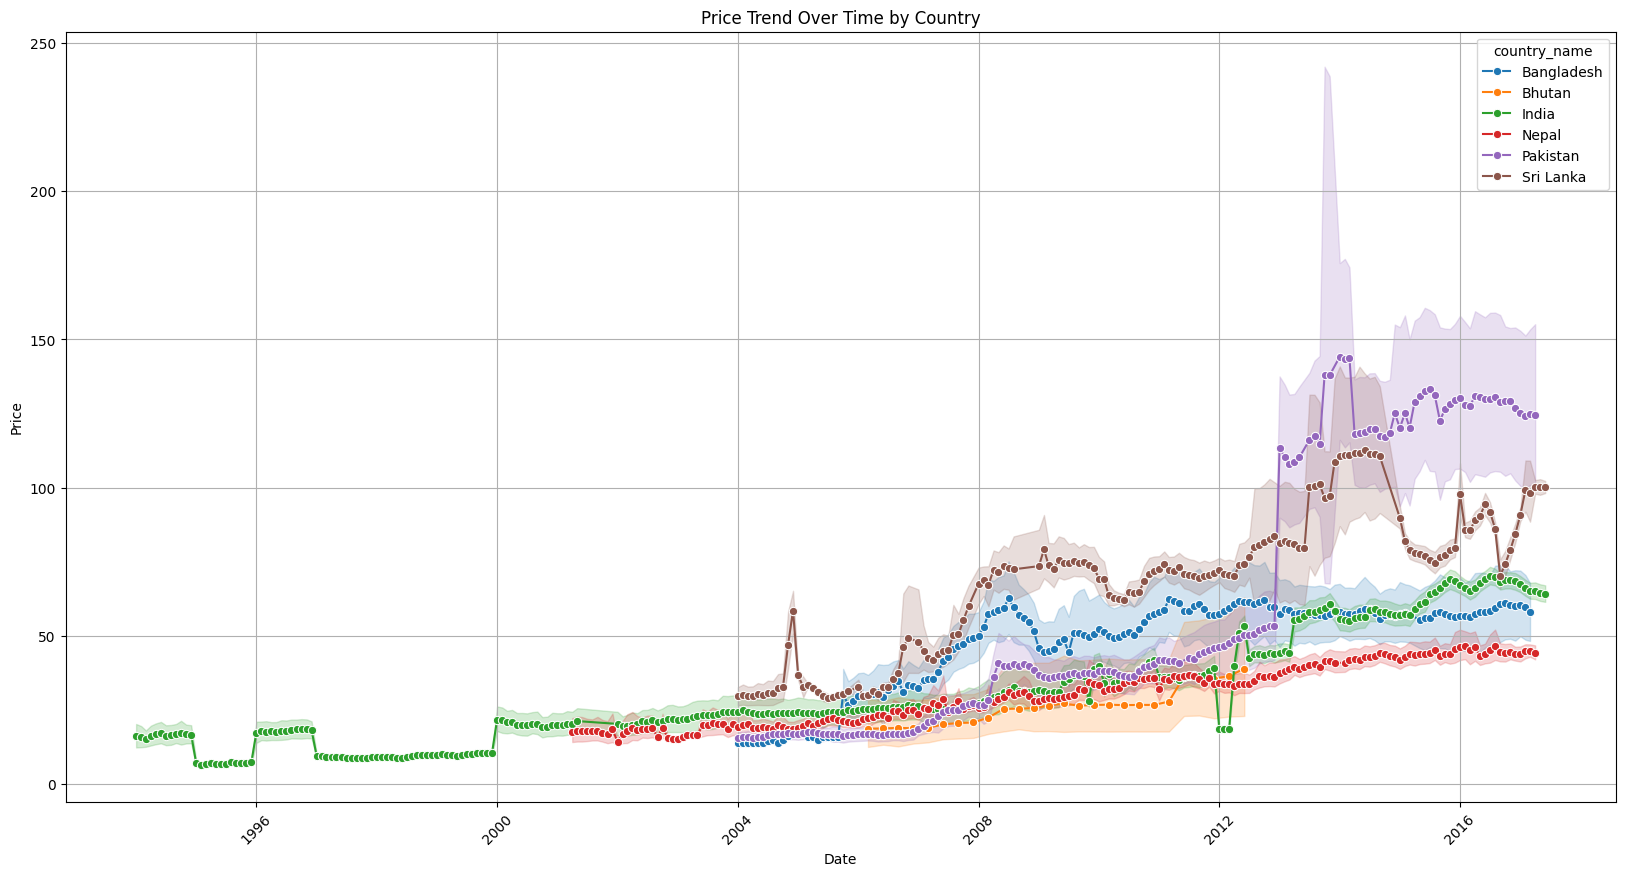

In [17]:
# Plot the data
plt.figure(figsize=(20,10))
sns.lineplot(data=M_food_prices_cleaned, x='date', y='price', hue='country_name', marker="o")

plt.title('Price Trend Over Time by Country')
plt.xlabel('Date')
plt.ylabel('Price')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

## Observations 

1. We can see that for most of the countries the price tracking started only after 2004. 
2. Pakistan saw a meteoric rise in prices compared to the other countries.
3. Since the prices are non-standard, this won't give us a clear picture of how they compare to each other


## Converting all the currency to USD from the native currency

Note: We are not accounting for the currency fluctuations over time and we take the latest currency values.

In [18]:
currency_conversion = {
    'BDT': 0.0091,   # Bangladeshi Taka to USD
    'BTN': 0.012,    # Bhutanese Ngultrum to USD (same as INR)
    'INR': 0.012,    # Indian Rupee to USD
    'NPR': 0.0075,   # Nepalese Rupee to USD
    'PKR': 0.0036,   # Pakistani Rupee to USD
    'LKR': 0.0031    # Sri Lankan Rupee to USD
}

In [19]:
# Function to convert prices to USD
def convert_to_usd(price, currency_code):
    if currency_code in currency_conversion:
        return price * currency_conversion[currency_code]
    else:
        return price  # If no conversion rate, leave the price unchanged

In [20]:
# Applying the conversion to the DataFrame
# Apply the conversion to the DataFrame
M_food_prices_cleaned['price_usd'] = M_food_prices_cleaned.apply(lambda row: convert_to_usd(row['price'], row['cur_name']), axis=1)

## Visualising the converted currency data

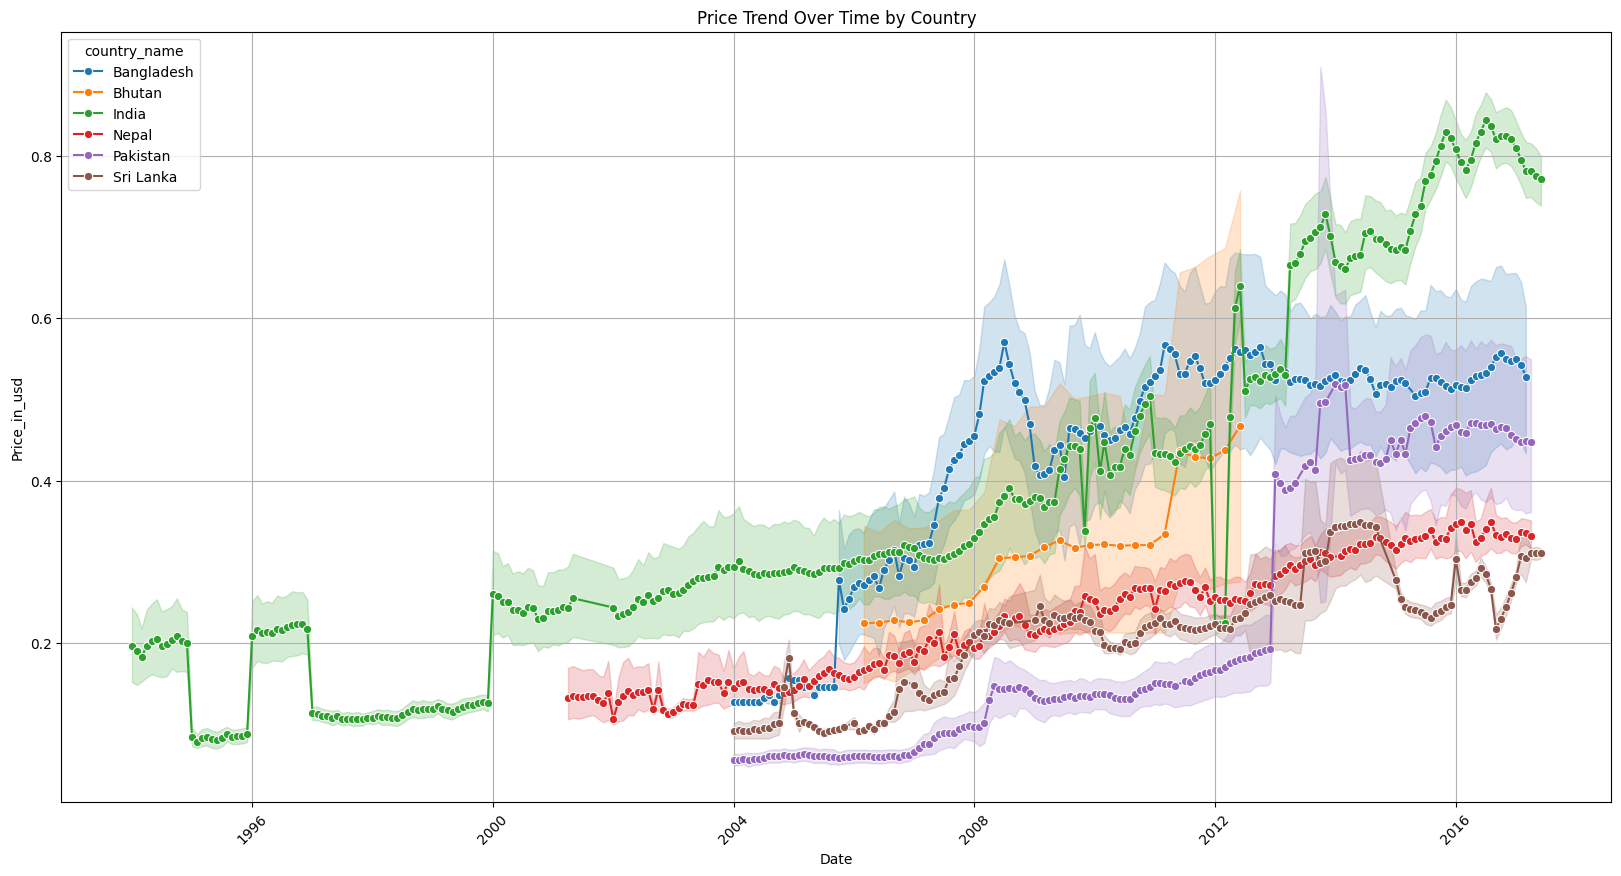

In [22]:
# Plot the data
plt.figure(figsize=(20,10))
sns.lineplot(data=M_food_prices_cleaned, x='date', y='price_usd', hue='country_name', marker="o")

plt.title('Price Trend Over Time by Country')
plt.xlabel('Date')
plt.ylabel('Price_in_usd')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

### Observations

We can observe that after standardizing the prices to USD, there is no longer a country with a drastic increase in price, most countries exhibit similar trend where the prices are steadily increasing.

## Detect Outliers using box plots

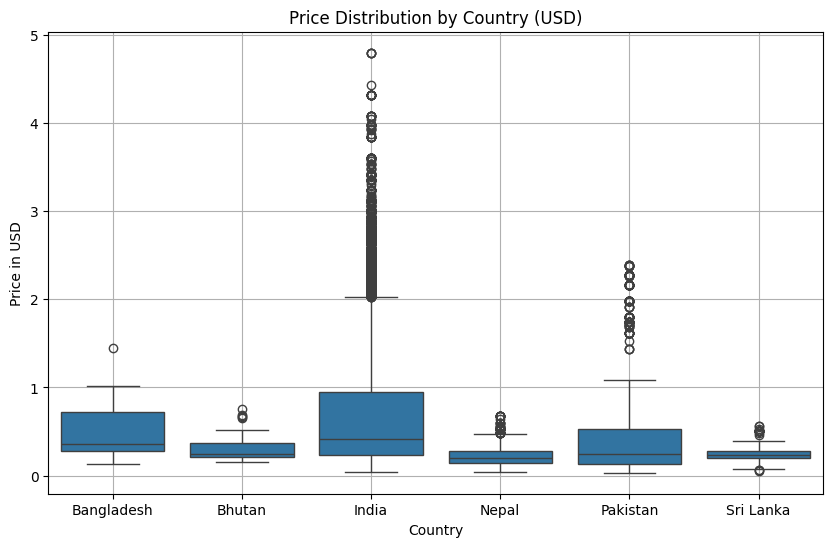

In [24]:
# Plot the boxplot to detect outliers
plt.figure(figsize=(10,6))
sns.boxplot(x='country_name', y='price_usd', data=M_food_prices_cleaned)

plt.title('Price Distribution by Country (USD)')
plt.xlabel('Country')
plt.ylabel('Price in USD')
plt.grid(True)
plt.show()

## Observations
We can see that there are many outliers in Country "India".

Pearson correlation coefficient: 0.3243385693983052
P-value: 0.0


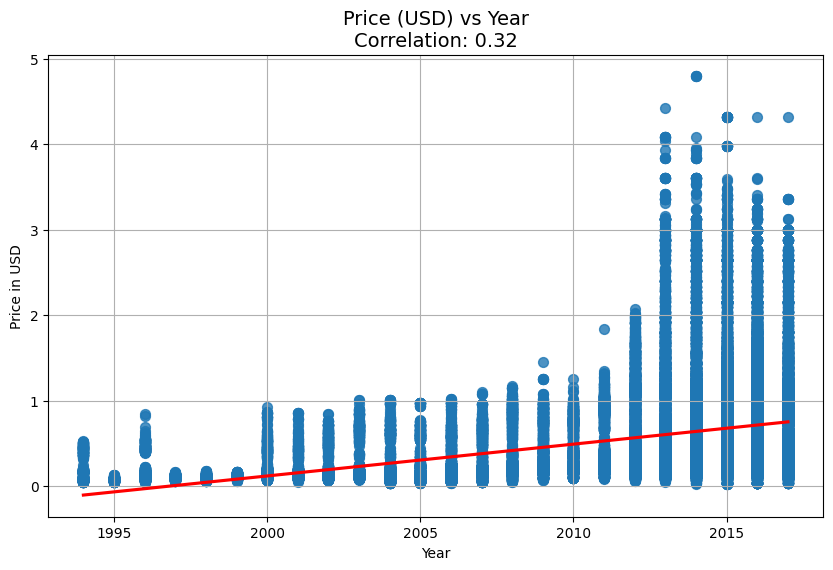

In [33]:
# Calculate Pearson correlation coefficient between price_year and price_usd
correlation, p_value = pearsonr(M_food_prices_cleaned['price_year'], M_food_prices_cleaned['price_usd'])
print(f"Pearson correlation coefficient: {correlation}")
print(f"P-value: {p_value}")

# Scatter plot with a regression line to show the relationship between year and price
plt.figure(figsize=(10,6))
sns.regplot(x='price_year', y='price_usd', data=M_food_prices_cleaned, scatter_kws={'s':50}, line_kws={'color':'red'})

# Customize the plot
plt.title(f'Price (USD) vs Year\nCorrelation: {correlation:.2f}', fontsize=14)
plt.xlabel('Year')
plt.ylabel('Price in USD')
plt.grid(True)
plt.show()

# Observations 

We see that there is a medium strong correlation between the price and the year.